In [1]:
import json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

In [2]:
imgs = sorted(Path("/hpcstor6/scratch01/a/anya.tongprasith001/2d_resized_256/images").glob("*.npz"))
meta_dir = Path("/hpcstor6/scratch01/a/anya.tongprasith001/2d_resized_256/metadata")

In [13]:
def show_one(i=0):
    p = imgs[i]
    x = np.load(p)["data"]
    meta = json.load(open(meta_dir / f"{p.stem}.json"))
    plt.figure(figsize=(1, 1))
    plt.imshow(x, cmap="gray")
    plt.axis("off")
    plt.show()
    print(meta)
    #print(meta["PatientID"])

In [14]:
print(len(imgs))

163568


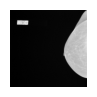

{'PatientID': 'DHARD4DRTHSZ', 'View': 'cranio-caudal', 'WindowCenter': [2491.0, 2515.0, 2455.0], 'WindowWidth': [900.0, 750.0, 1050.0], 'WindowCenterWidthExplanation': ['NORMAL', 'HARDER', 'SOFTER'], 'ImagerPixelSpacing': [0.09409090909091, 0.09409090909091], 'ImageLaterality': 'R', 'coords': [241, 106, 254, 125], 'score': 0.03152620047330856, 'label': 'NonCancer'}


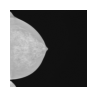

{'PatientID': 'DH1AJLIW8A7B', 'View': 'cranio-caudal', 'WindowCenter': [3055.0, 3091.0, 2995.0], 'WindowWidth': [900.0, 750.0, 1050.0], 'WindowCenterWidthExplanation': ['NORMAL', 'HARDER', 'SOFTER'], 'ImagerPixelSpacing': [0.09409090909091, 0.09409090909091], 'ImageLaterality': 'L', 'coords': [0, 65, 18, 77], 'score': 0.048385247588157654, 'label': 'NonCancer'}


In [27]:
show_one(0)
show_one(1)

In [65]:
cancer = []
non_cancer = []
def check_cancer(i=0):
    p = imgs[i]
    x = np.load(p)["data"]
    meta = json.load(open(meta_dir / f"{p.stem}.json"))
    if meta["label"] != "NonCancer" :
        cancer.append(p)
    else :
        non_cancer.append(p)

In [66]:
for i in range(len(imgs)) :
    check_cancer(i)
print(len(cancer))
print(len(non_cancer))

9330
154238


In [67]:
labels = {}
cancer_meta = {}
non_cancer_meta = {}
for img in cancer :
    x = np.load(img)["data"]
    meta = json.load(open(meta_dir / f"{img.stem}.json"))
    cancer_meta[img] = meta
print("Go through all cancer patient scans")
for img in non_cancer :
    x = np.load(img)["data"]
    meta = json.load(open(meta_dir / f"{img.stem}.json"))
    non_cancer_meta[img] = meta
print("Go through all non-cancer patient scans")

Go through all cancer patient scans
Go through all non-cancer patient scans


In [72]:
cancer_left = 0
cancer_right = 0
cancer_unknown = 0
non_cancer_left = 0
non_cancer_right = 0
non_cancer_unknown = 0

for img in cancer_meta.keys():
    side = cancer_meta[img]["ImageLaterality"]
    if side == "L" :
        cancer_left += 1
    elif side == "R" :
        cancer_right += 1
    else :
        cancer_unknown += 1

for img in non_cancer_meta.keys():
    side = non_cancer_meta[img]["ImageLaterality"]
    if side == "L" :
        non_cancer_left += 1
    elif side == "R" :
        non_cancer_right += 1
    else :
        non_cancer_unknown += 1

print("Cancer patients : " + str(len(cancer)))
print("Left breast : " + str(cancer_left))
print("Right breast : " + str(cancer_right))
print("Unknown : " + str(cancer_unknown))
print()
print("Non-cancer patients : " + str(len(non_cancer)))
print("Left breast : " + str(non_cancer_left))
print("Right breast : " + str(non_cancer_right))
print("Unknown : " + str(non_cancer_unknown))

Cancer patients : 9330
Left breast : 4883
Right breast : 4447
Unknown : 0

Non-cancer patients : 154238
Left breast : 76640
Right breast : 77598
Unknown : 0


Cancer images :
Score means = 0.4949293707630241


<function matplotlib.pyplot.show(close=None, block=None)>

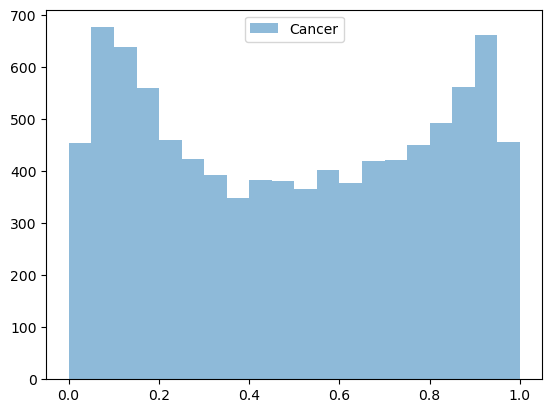

In [86]:
cancer_scores = []
for img in cancer_meta.keys() :
    score = cancer_meta[img]["score"]
    cancer_scores.append(score)
print("Cancer images :")
print("Score means = " + str(np.mean(cancer_scores)))
plt.hist(cancer_scores, bins = 20, alpha = 0.5, label = "Cancer")
plt.legend()
plt.show

Non-cancer images :
Average score = 0.1927413677309449


<function matplotlib.pyplot.show(close=None, block=None)>

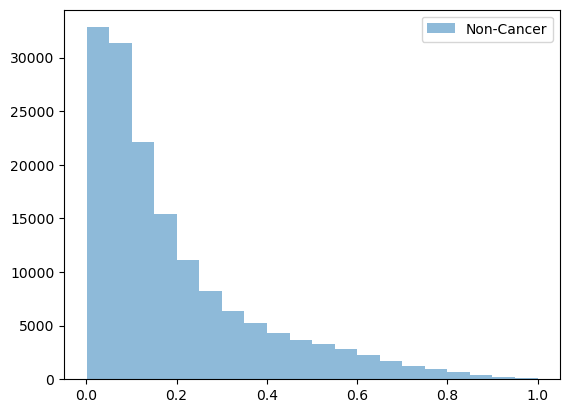

In [87]:
non_cancer_scores = []
for img in non_cancer_meta.keys() :
    score = non_cancer_meta[img]["score"]
    non_cancer_scores.append(score)
print("Non-cancer images :")
print("Average score = " + str(np.mean(non_cancer_scores)))
plt.hist(non_cancer_scores, bins = 20, alpha = 0.5, label = "Non-Cancer")
plt.legend()
plt.show

In [71]:
labels = {}
for img in cancer_meta.keys():
    label = cancer_meta[img]["label"]
    if label not in labels.keys() :
        labels[label] = {}

    view = cancer_meta[img]["View"]
    if view not in labels[label].keys() :
        labels[label][view] = 0
    labels[label][view] += 1

for l in labels.keys() :
    l_count = 0
    print(str(l))
    for v, count in labels[l].items() :
        print(v, count)
        l_count += count
    print("Total : " + str(l_count))
    print()

Unknown
cranio-caudal 1003
medio-lateral oblique 974
craniocaudal 1
mediolateral oblique 1
Total : 1979

IndexCancer
cranio-caudal 3270
medio-lateral oblique 2532
mediolateral oblique 1
Total : 5803

PreIndexCancer
medio-lateral oblique 752
cranio-caudal 796
Total : 1548

